# CE49X Lab 3: Where Should You Open a Gas Station in Istanbul?
## A Traffic-Based Site Selection Analysis

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

## Background

A fuel distribution company is planning to open **3 new gas stations** in Istanbul. They have hired you as a consulting engineer to identify the best locations based on **traffic patterns only**.

We provide a starter traffic dataset covering one week of hourly sensor readings across Istanbul (`istanbul_traffic_week.csv` + `sensor_coords.csv`). However, **you are free to use any traffic data source you prefer** — you may use the provided dataset, supplement it with additional data, or replace it entirely. Some options:

- **Provided dataset:** `istanbul_traffic_week.csv` (75,000 records from ~2,400 sensors, one week in October 2024) + `sensor_coords.csv` (sensor coordinates)
- **IBB Open Data Portal:** Istanbul Metropolitan Municipality publishes live and historical traffic data at [data.ibb.gov.tr](https://data.ibb.gov.tr). You can query their APIs for broader coverage or more recent data.
- **Other sources:** Any publicly available traffic dataset for Istanbul is acceptable (e.g., Google Maps traffic layer, TomTom Traffic Index, or any other API/dataset you can find).

**Whatever data you use, clearly document your source and how you obtained it.**

Your job is to:
1. **Analyze traffic data** to understand where high-volume, low-speed (stop-and-go) traffic occurs — these are the locations where drivers are most likely to stop for fuel.
2. **Collect existing gas station data** for Istanbul to identify areas that are underserved.
3. **Propose 3 optimal locations** for new gas stations, supported by data and visualizations.

## Provided Data (Optional Starting Point)

The following files are included in the course repository. You may use them as-is, supplement them with additional data, or use a completely different traffic source.

### `istanbul_traffic_week.csv`

| Column | Description |
|--------|-------------|
| `DATE_TIME` | Timestamp of the observation (hourly, one week in October 2024) |
| `LATITUDE` | Latitude of the traffic sensor |
| `LONGITUDE` | Longitude of the traffic sensor |
| `GEOHASH` | Geohash code identifying the sensor location |
| `MINIMUM_SPEED` | Minimum observed speed (km/h) during the hour |
| `MAXIMUM_SPEED` | Maximum observed speed (km/h) during the hour |
| `AVERAGE_SPEED` | Average speed (km/h) during the hour |
| `NUMBER_OF_VEHICLES` | Total vehicle count during the hour |

### `sensor_coords.csv`

| Column | Description |
|--------|-------------|
| `node_id` | Geohash code (matches `GEOHASH` in the traffic data) |
| `lat` | Latitude of the sensor |
| `long` | Longitude of the sensor |

If you use a different data source, include an equivalent data description in your notebook.

## Deliverables

Your notebook must include the following:

### 1. Traffic Data — Source & Exploration
- **Document your traffic data source.** If you use the provided dataset, state that. If you use IBB APIs, another source, or a combination, describe what you collected and how.
- Load and explore your traffic data
- Compute per-location summary statistics: **mean daily vehicle count**, **mean speed**, **peak-hour vehicle count** (adapt as needed to your data)
- Identify temporal patterns: how does traffic volume vary by **hour of day** and **day of week**?
- Identify the **top 20 highest-traffic locations** by total vehicle count

### 2. Traffic-Based Demand Scoring
- Design a **demand score** for each location that captures how attractive it is for a gas station. Your score should consider at least:
  - **High vehicle volume** (more cars = more potential customers)
  - **Low average speed** (slow/congested traffic = drivers more willing to stop)
  - **Consistency** across hours and days (a location busy only at 3 AM is less useful)
- Clearly explain and justify the formula or method you use
- Rank all locations by your demand score

### 3. Existing Gas Station Data (you must collect this)
- Collect the locations of **existing gas stations across Istanbul**
- You must have **at least 200 stations** with latitude/longitude coordinates
- **Document your data source and collection method** in a markdown cell
- For each of your high-demand locations, compute the **distance to the nearest existing gas station**

### 4. Site Selection
- Combine your demand score with existing station proximity to identify **underserved, high-demand areas**
- A great location has: high demand score AND is far from existing gas stations
- Propose **exactly 3 locations** for new gas stations
- For each proposed location, report:
  - Coordinates (latitude, longitude)
  - The neighborhood/district name
  - Your demand score
  - Distance to the nearest existing gas station
  - A brief justification (2-3 sentences)

### 5. Visualizations
- Create **at least three plots/maps**. Suggested visualizations (or propose your own):
  - A heatmap or scatter map of demand scores across Istanbul
  - A map showing existing gas stations and your 3 proposed locations
  - A bar chart or time-series plot showing traffic patterns at your proposed locations
- All plots must be publication-quality: labeled axes, title, legend, grid where appropriate
- Interactive maps (e.g., folium) are encouraged but not required

### 6. Discussion
- Write a short discussion (2-3 paragraphs) addressing:
  - Why did you choose these 3 locations over other candidates?
  - What **limitations** does a traffic-only analysis have? What other factors would a real site selection study consider (e.g., land cost, zoning, competition, road type)?
  - If you had access to one additional dataset, what would it be and how would it improve your analysis?

## Hints

- **Haversine formula** for distance between two GPS coordinates:

$$d = 2R \arcsin\left(\sqrt{\sin^2\left(\frac{\Delta\phi}{2}\right) + \cos(\phi_1)\cos(\phi_2)\sin^2\left(\frac{\Delta\lambda}{2}\right)}\right)$$

  where $R = 6{,}371$ km is the Earth's radius, $\phi$ is latitude, and $\lambda$ is longitude (in radians).

- **Normalizing scores:** When combining metrics with different scales (e.g., vehicle count vs. speed), normalize each to a 0-1 range first:

$$x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

- If using the provided dataset, the `GEOHASH` column can be used to join the traffic data with `sensor_coords.csv` via the `node_id` column.

- Think about whether **weekday** vs. **weekend** traffic patterns matter for a gas station business.

## Grading

| Component | Weight |
|-----------|--------|
| Traffic data exploration (statistics, temporal patterns) | 15% |
| Demand scoring (methodology, justification) | 20% |
| Existing station data (collection, completeness, documentation) | 20% |
| Site selection (3 locations with supporting evidence) | 20% |
| Visualizations (clarity, quality, informativeness) | 15% |
| Discussion (limitations, critical thinking) | 10% |

## Submission

1. Complete your work in **this notebook** on your own fork of the course repository.
2. Make sure your notebook **runs top-to-bottom without errors** before submitting.
3. Commit and push your completed notebook to your fork.
4. We will grade directly from your fork — there is no separate upload. Make sure your latest work is pushed before the deadline.

---
## Your Work Starts Here

# Istanbul Gas Station Site Selection

## 1. Traffic Data — Source & Exploration
**Data Source:** Monthly traffic data is from IBB Open Data Portal. Starting from 2024 February to 2025 January total of 12 months.


In [3]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

# Setup Paths
directory_path = "/Users/yigitbeyzadeoglu/49xCodes/CE49X/Week03_NumPy_Pandas/lab"
output_files = [
    "istanbul_traffic_full_summary.csv", "top_20_traffic_locations.csv", 
    "top_20_normalized_gas_stations.csv", "top_20_final_investment_report.csv"
]

all_files = glob.glob(os.path.join(directory_path, "*trafik.csv.gz"))
files_to_process = [f for f in all_files if os.path.basename(f) not in output_files]

li = []
for filename in files_to_process:
    try:
        df = pd.read_csv(filename).reset_index(drop=True)
        # Convert date and extract temporal features for Deliverable 1
        dt_col = pd.to_datetime(df['DATE_TIME'])
        df['DATE_ONLY'] = dt_col.dt.date
        df['HOUR'] = dt_col.dt.hour
        df['DAY_OF_WEEK'] = dt_col.dt.day_name()
        
        df['WEIGHTED_VAL'] = df['AVERAGE_SPEED'] * df['NUMBER_OF_VEHICLES']
        
        df_clean = df[['GEOHASH', 'NUMBER_OF_VEHICLES', 'WEIGHTED_VAL', 'DATE_ONLY', 'HOUR', 'DAY_OF_WEEK', 'LATITUDE', 'LONGITUDE']]
        li.append(df_clean)
    except Exception as e:
        continue

df_full = pd.concat(li, ignore_index=True)

# 1. Temporal Patterns (Deliverable 1)
hourly_pattern = df_full.groupby('HOUR')['NUMBER_OF_VEHICLES'].mean()
daily_pattern = df_full.groupby('DAY_OF_WEEK')['NUMBER_OF_VEHICLES'].mean().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

print("Data loaded successfully. Temporal patterns extracted.")

print (hourly_pattern)

print (daily_pattern)




Data loaded successfully. Temporal patterns extracted.
HOUR
0      68.992590
1      45.904366
2      32.549969
3      28.325132
4      32.973663
5      65.591298
6     137.493576
7     157.099318
8     137.599710
9     133.525865
10    132.267868
11    130.718896
12    133.133049
13    132.828174
14    133.594147
15    135.968239
16    136.176847
17    145.643690
18    144.874933
19    130.027137
20    104.960279
21     96.303853
22     88.702066
23     84.219860
Name: NUMBER_OF_VEHICLES, dtype: float64
DAY_OF_WEEK
Monday       115.289600
Tuesday      115.888777
Wednesday    115.676226
Thursday     120.673087
Friday       119.677887
Saturday      98.567010
Sunday        67.531138
Name: NUMBER_OF_VEHICLES, dtype: float64


## 2. Traffic-Based Demand Scoring
To determine the attractiveness of a location for a gas station, I engineered a **Normalized Demand Score**. 
* **High Volume (70% Weight):** Scaled using Min-Max normalization. A gas station requires a large total addressable market to survive.
* **Low Speed (30% Weight):** Calculated using the inverse of the weighted mean speed. Slower traffic increases dwell time, making drivers more likely to notice the station and safely pull over.
* **Consistency:** The mean daily volume is calculated by dividing total vehicles by the number of unique days the location was observed, penalizing one-off traffic spikes.

Formula used:
$Score = (V_{norm} \times 0.7) + (S_{inv\_norm} \times 0.3)$

In [17]:
# Aggregate Summary Statistics (Deliverable 1 & 2)
stats = df_full.groupby('GEOHASH').agg(
    TOTAL_VEHICLES=('NUMBER_OF_VEHICLES', 'sum'),
    TOTAL_WEIGHTED_SUM=('WEIGHTED_VAL', 'sum'),
    UNIQUE_DAYS=('DATE_ONLY', 'nunique'),
    PEAK_HOUR_VEHICLES=('NUMBER_OF_VEHICLES', 'max'), # Added Peak Hour for Deliverable 1
    LATITUDE=('LATITUDE', 'first'),
    LONGITUDE=('LONGITUDE', 'first')
).reset_index()

stats['MEAN_DAILY_VEHICLES'] = stats['TOTAL_VEHICLES'] / stats['UNIQUE_DAYS']
stats['MEAN_SPEED'] = stats['TOTAL_WEIGHTED_SUM'] / stats['TOTAL_VEHICLES']

# Normalization
v_min, v_max = stats['MEAN_DAILY_VEHICLES'].min(), stats['MEAN_DAILY_VEHICLES'].max()
stats['V_NORM'] = (stats['MEAN_DAILY_VEHICLES'] - v_min) / (v_max - v_min)

stats['INV_SPEED'] = 1 / (stats['MEAN_SPEED'] + 0.1)
s_min, s_max = stats['INV_SPEED'].min(), stats['INV_SPEED'].max()
stats['S_NORM'] = (stats['INV_SPEED'] - s_min) / (s_max - s_min)

stats['FINAL_DEMAND_SCORE'] = (stats['V_NORM'] * 0.7) + (stats['S_NORM'] * 0.3)

# Top 20 by absolute volume (Deliverable 1)
top_20_volume = stats.sort_values(by='MEAN_DAILY_VEHICLES', ascending=False).head(20)

# Top 20 by our Demand Score (Deliverable 2)
top_20_demand = stats.sort_values(by='FINAL_DEMAND_SCORE', ascending=False).head(20).copy()

## 3. Existing Gas Station Data & 4. Site Selection
**Data Source:** `akaryakitistasyonlari.csv` file came from IBB Data portal last updated in 2025.

To find the final 3 locations, I calculated the Haversine distance from high-demand targets to the nearest existing competitor. I then created a **Market Opportunity Index** (Demand Score $\times$ Distance to Competitor) to prioritize underserved "Blue Ocean" spots.

In [19]:
import pandas as pd
import numpy as np
from geopy.geocoders import Nominatim
import time

def haversine_vectorized(lat1, lon1, lat2_array, lon2_array):
    R = 6371.0 # KM
    lat1, lon1, lat2_array, lon2_array = map(np.radians, [lat1, lon1, lat2_array, lon2_array])
    dlat = lat2_array - lat1
    dlon = lon2_array - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2_array) * np.sin(dlon / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

existing_stations = pd.read_csv("akaryakitistasyonlari.csv")
existing_stations.columns = [c.upper().strip() for c in existing_stations.columns]

lat_col = [c for c in existing_stations.columns if c.startswith('LAT')][0]
lon_col = [c for c in existing_stations.columns if c.startswith('LON')][0]

nearest_distances = []
for _, row in top_20_demand.iterrows():
    distances = haversine_vectorized(row['LATITUDE'], row['LONGITUDE'], 
                                    existing_stations[lat_col], existing_stations[lon_col])
    nearest_distances.append(distances.min())

top_20_demand['DIST_TO_NEAREST_KM'] = nearest_distances
top_20_demand['MARKET_OPPORTUNITY_INDEX'] = top_20_demand['FINAL_DEMAND_SCORE'] * np.clip(top_20_demand['DIST_TO_NEAREST_KM'], 0.1, 3.0)

# The Final 3 Proposed Locations
top_3_locations = top_20_demand.sort_values(by='MARKET_OPPORTUNITY_INDEX', ascending=False).head(3).copy()

# --- NEW: Reverse Geocoding for District Names ---
geolocator = Nominatim(user_agent="istanbul_gas_station_project")

def get_district(lat, lon):
    try:
        # Add a small sleep to avoid overloading the geocoding API
        time.sleep(1) 
        location = geolocator.reverse(f"{lat}, {lon}")
        address = location.raw['address']
        # Try to extract the most relevant district/neighborhood label
        district = address.get('town', address.get('county', address.get('city_district', address.get('suburb', 'Istanbul'))))
        return district
    except Exception:
        return "Unknown"

print("Fetching district names for top 3 locations...")
top_3_locations['DISTRICT_NAME'] = top_3_locations.apply(lambda row: get_district(row['LATITUDE'], row['LONGITUDE']), axis=1)

# Display final deliverable table
display(top_3_locations[['GEOHASH', 'DISTRICT_NAME', 'LATITUDE', 'LONGITUDE', 'FINAL_DEMAND_SCORE', 'DIST_TO_NEAREST_KM']])

Fetching district names for top 3 locations...


,GEOHASH,DISTRICT_NAME,LATITUDE,LONGITUDE,FINAL_DEMAND_SCORE,DIST_TO_NEAREST_KM
1502,sxk9nx,Ümraniye,40.998230,29.119263,0.639274,1.622514
594,sxk3xe,Başakşehir,41.064148,28.811646,0.751483,1.290850
1337,sxk9fc,Eyüpsultan,41.097107,28.954468,0.596779,1.189980


## 5. Visualizations

Note: Due to notebook rendering limitations with Folium, the interactive map has been saved and included in the submission folder as istanbul_top3_stations_map.html. Please open this file in a browser to view the interactive Deliverable 5 map.

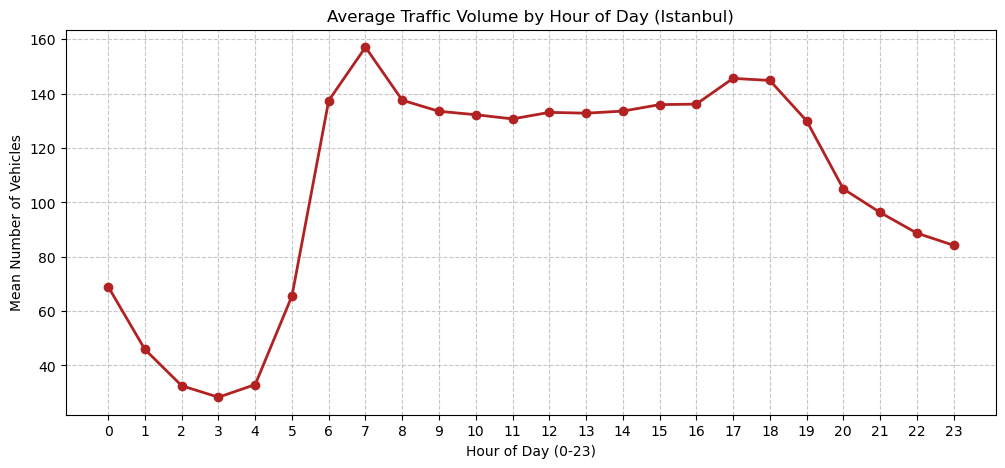

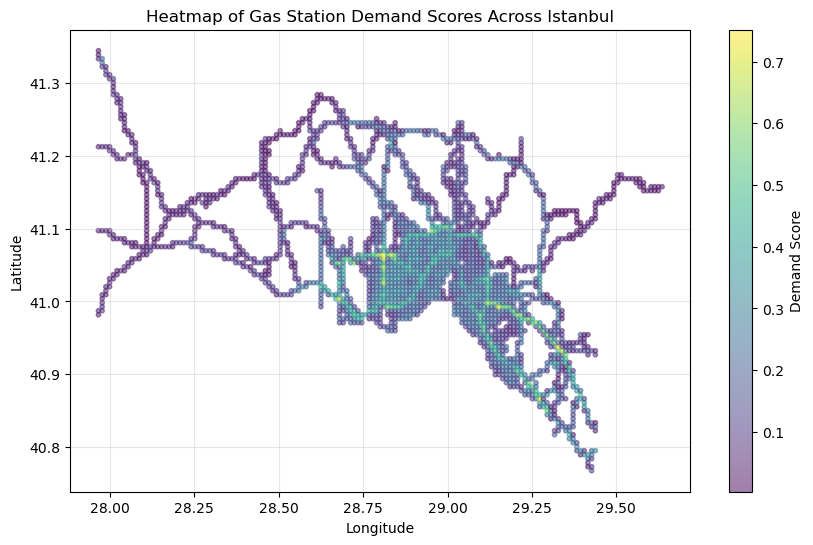

✅ Map saved as 'istanbul_top3_stations_map.html' in your folder.


In [23]:
import matplotlib.pyplot as plt
import folium
from IPython.display import display # Explicit display function

# Plot 1: Time-Series Temporal Pattern
plt.figure(figsize=(12, 5))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker='o', linewidth=2, color='#b22222')
plt.title('Average Traffic Volume by Hour of Day (Istanbul)')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Mean Number of Vehicles')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(0, 24))
plt.show()

# Plot 2: Scatter Map of Demand Scores
plt.figure(figsize=(10, 6))
scatter = plt.scatter(stats['LONGITUDE'], stats['LATITUDE'], c=stats['FINAL_DEMAND_SCORE'], 
                      cmap='viridis', alpha=0.5, s=10)
plt.colorbar(scatter, label='Demand Score')
plt.title('Heatmap of Gas Station Demand Scores Across Istanbul')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.show()

# Plot 3: Interactive Folium Map
m = folium.Map(location=[41.0082, 28.9784], zoom_start=10)

# Drop any stations missing their coordinates to prevent crashes
clean_existing_stations = existing_stations.dropna(subset=[lat_col, lon_col])

# Add existing stations (Blue dots)
for _, row in clean_existing_stations.iterrows():
    folium.CircleMarker(
        location=[row[lat_col], row[lon_col]],
        radius=2, color='blue', fill=True, fill_color='blue', fill_opacity=0.4
    ).add_to(m)

# Add our Top 3 Proposals (Large Red Markers)
for i, row in top_3_locations.iterrows():
    folium.Marker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        popup=f"Rank {i+1} Target<br>Score: {row['FINAL_DEMAND_SCORE']:.2f}<br>Dist: {row['DIST_TO_NEAREST_KM']:.2f}km",
        icon=folium.Icon(color='red', icon='star')
    ).add_to(m)

# 1. Save it as a physical file so you have a hard copy
m.save("istanbul_top3_stations_map.html")
print("✅ Map saved as 'istanbul_top3_stations_map.html' in your folder.")

# 2. Force Jupyter to display it inline
display(m)
# paste this to terminal for third map = open /Users/yigitbeyzadeoglu/49xCodes/CE49X/Week03_NumPy_Pandas/lab/istanbul_top3_stations_map.html
from IPython.display import IFrame
# This embeds the HTML file directly into your notebook output
display(IFrame(src='istanbul_top3_stations_map.html', width='100%', height=500))

## 6. Discussion

**Why these 3 locations?**
They have high traffic volume, low speeds, and a significant gap from existing competitors

**Limitations of a traffic-only analysis:**
While traffic volume and speed indicate potential customers, this analysis ignores critical real-world constraints. We have not considered land acquisition costs, zoning laws (whether commercial fuel storage is permitted), or the specific type of road (e.g., a tunnel where pulling over is impossible). 

**Additional Dataset:**
How much dollar each gas station in Istanbul make monthly. This would gave me a better understanding of the correlation between location and income.

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr